In [2]:
import numpy as np 
from matplotlib import pyplot as plt 

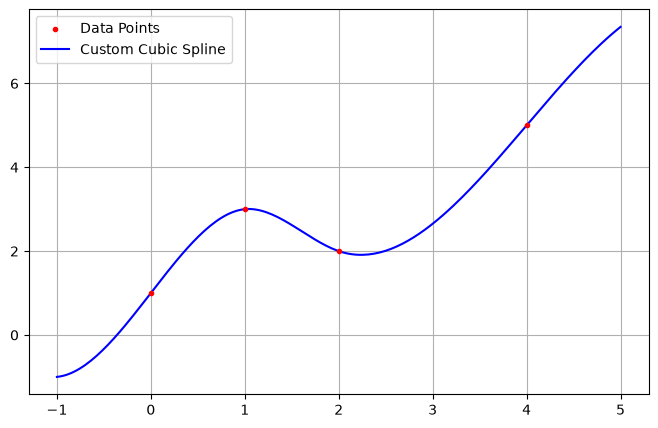

In [27]:
def compute_natural_cubic_spline(x, y):
    """
    Computes coefficients for the piecewise cubic polynomials:
    S_i(x) = a_i + b_i*(x - x_i) + c_i*(x - x_i)^2 + d_i*(x - x_i)^3
    """
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)
    n = len(x)
    
    # 1. Widths of the intervals
    h = np.diff(x)
    
    # 2. Set up the linear system system: A * c = B
    A = np.zeros((n, n))
    B = np.zeros(n)
    
    # Natural boundary conditions: second derivative at endpoints is 0
    A[0, 0] = 1.0
    A[n-1, n-1] = 1.0
    
    # Fill the tridiagonal matrix based on continuity conditions
    for i in range(1, n-1):
        A[i, i-1] = h[i-1]
        A[i, i] = 2 * (h[i-1] + h[i])
        A[i, i+1] = h[i]
        B[i] = 3 * ((y[i+1] - y[i]) / h[i] - (y[i] - y[i-1]) / h[i-1])
        
    # 3. Solve for 'c' coefficients
    c = np.linalg.solve(A, B)
    
    # 4. Derive 'a', 'b', and 'd' coefficients from 'c'
    a = y[:-1]
    b = np.zeros(n - 1)
    d = np.zeros(n - 1)
    
    for i in range(n - 1):
        b[i] = (y[i+1] - y[i]) / h[i] - h[i] * (2 * c[i] + c[i+1]) / 3
        d[i] = (c[i+1] - c[i]) / (3 * h[i])
        
    return a, b, c[:-1], d

def evaluate_spline(x_query, x_data, a, b, c, d):
    """Evaluates the spline at given query coordinates."""
    y_query = []
    for x_val in x_query:
        # Find which interval the query point falls into
        if x_val <= x_data[0]:
            i = 0
        elif x_val >= x_data[-2]:
            i = len(x_data) - 2
        else:
            # Binary search to locate interval index
            i = np.searchsorted(x_data, x_val) - 1
            
        dx = x_val - x_data[i]
        val = a[i] + b[i]*dx + c[i]*(dx**2) + d[i]*(dx**3)
        y_query.append(val)
        
    return np.array(y_query)

# --- Execution & Verification ---

# Define original data points (x must be strictly increasing)
x_points = np.array([0.0, 1.0, 2.0, 4.0])
y_points = np.array([1.0, 3.0, 2.0, 5.0])

# Step 1: Extract polynomial coefficients
a, b, c, d = compute_natural_cubic_spline(x_points, y_points)

# Step 2: Evaluate on a dense grid for smooth plotting
x_dense = np.linspace(-1, 5, 200)
y_dense = evaluate_spline(x_dense, x_points, a, b, c, d)


# Plot results
plt.figure(figsize=(8, 5))
plt.scatter(x_points, y_points, color='red', label='Data Points', zorder=5, marker='.')
plt.plot(x_dense, y_dense, color='blue', label='Custom Cubic Spline')
plt.grid(True)
plt.legend()
plt.show()
